In [115]:
import os
import io
import time
from datetime import datetime

from PIL import Image
import win32clipboard

from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.common.action_chains import ActionChains
from selenium.common.exceptions import TimeoutException, NoSuchElementException, NoAlertPresentException

from webdriver_manager.chrome import ChromeDriverManager
from urllib.parse import urlparse

In [116]:
# expedia_url = "https://console.vap.expedia.com/analytics-console-user-interface/optics/agentRealtime"
# teams_url = "https://teams.microsoft.com/"
# # group_chat_name = "Huu Chinh Nguyen"
# parsed_url = urlparse(expedia_url)
# path_fragment = parsed_url.path.split('/')[-1]
# report_name = "Long chat"
# wait_seconds = 10
# start_time = datetime.now()

# chrome_options = Options()
# chrome_options.add_argument(r'--user-data-dir=C:/temp/new_chrome_profile')
# chrome_options.add_argument(r'--profile-directory=Default')
# chrome_options.add_argument("--start-maximized")

# service = Service(ChromeDriverManager().install())


# service = Service(r"C:\Users\huuchinh.nguyen\Concentrix Corporation\WFM-Expedia-HCM - Branding files\Rawdata\CAPTURE\chromedriver-win64\chromedriver.exe") 
# driver = webdriver.Chrome(service=service, options=chrome_options)


# def send_to_clipboard(image):
#     output = io.BytesIO()
#     image.convert("RGB").save(output, "BMP")
#     data = output.getvalue()[14:]
#     output.close()

#     win32clipboard.OpenClipboard()
#     win32clipboard.EmptyClipboard()
#     win32clipboard.SetClipboardData(win32clipboard.CF_DIB, data)
#     win32clipboard.CloseClipboard()
#     print("Image copied to clipboard!")
    

# wait = WebDriverWait(driver, 15)
# driver.get(expedia_url)

# def check_and_login(driver, expedia_url, wait_time=10):
#     driver.get(expedia_url)
#     time.sleep(10)

#     try:
#         sign_in_button = WebDriverWait(driver, 10).until(
#             EC.element_to_be_clickable((By.CSS_SELECTOR, 'button[data-testid="console-okta-sign-in"]'))
#         )
#         print("🔑 Sign-in required detected! Clicking...")
#         sign_in_button.click()
#         time.sleep(2)
#         try:
#             keep_signed_in_label = WebDriverWait(driver, 10).until(
#                 EC.element_to_be_clickable((By.CSS_SELECTOR, 'label[for="input36"][data-se-for-name="rememberMe"]'))
#             )
#             keep_signed_in_label.click()
#             time.sleep(1)
#         except TimeoutException:
#             print("No 'Keep me signed in' option found. Skipping.")
#         try:
#             next_button = WebDriverWait(driver, 10).until(
#                 EC.element_to_be_clickable((By.CSS_SELECTOR, 'input.button.button-primary[type="submit"][value="Next"]'))
#             )
#             next_button.click()
#             time.sleep(10)
#         except TimeoutException:
#             print("No 'Next' button found. Skipping.")
#         print("🎉 Login successful! Reloading the page...")
#         try:
#             alert = driver.switch_to.alert
#             alert.accept()
#         except NoAlertPresentException:
#             print("No 'Alert' button found. Skipping.")

        
#         driver.get(expedia_url)
#     except TimeoutException:
#         print("✅ No sign-in required. Continuing with expedia_url...")

# check_and_login(driver, expedia_url)

# wait = WebDriverWait(driver, 10)

# try:
#     target_btn = wait.until(lambda d: d.execute_script("""
#         const titleEl = Array.from(document.querySelectorAll('*')).find(el =>
#             el.childNodes.length === 1 &&
#             el.childNodes[0].nodeType === Node.TEXT_NODE &&
#             el.textContent.trim() === 'Assigned Workitem (Connect)'
#         );
#         if (!titleEl) return null;

#         let node = titleEl.parentElement;
#         while (node && node !== document.body) {
#             const btns = node.querySelectorAll('button.settingsButton');
#             if (btns.length === 1) return btns[0];
#             node = node.parentElement;
#         }
#         return null;
#     """))

#     if target_btn is None:
#         raise Exception("Không tìm thấy settingsButton của 'Assigned Workitem (Connect)'")

#     print("✅ Found settingsButton (Connect)")
#     driver.execute_script("arguments[0].scrollIntoView({block:'center'});", target_btn)
#     time.sleep(0.5)
#     driver.execute_script("arguments[0].click();", target_btn)
#     print("✅ Clicked settingsButton")

#     wait.until(EC.presence_of_element_located(
#         (By.CSS_SELECTOR, "div.uitk-menu-container[aria-hidden='false']")
#     ))

#     download_csv_button = wait.until(
#         EC.element_to_be_clickable((
#             By.XPATH,
#             "//div[contains(@class,'uitk-menu-open')][@aria-hidden='false']"
#             "//span[text()='Download CSV']/ancestor::button"
#         ))
#     )
#     download_csv_button.click()
#     print("✅ Clicked Download CSV")

# except Exception as e:
#     print(f"❌ Lỗi: {e}")

# wait = WebDriverWait(driver, 10)
# wait.until(EC.url_contains(path_fragment))
# time.sleep(wait_seconds)

In [117]:
# import shutil
# import glob 

# source_folder = r"C:\temp\expedia_downloads"
# destination_folder = r"C:\Users\huuchinh.nguyen\Concentrix Corporation\WFM-Expedia-HCM - Branding files\Rawdata\CAPTURE\lc_rawdata_in_console"

# file_patterns = [os.path.join(source_folder, "Assigned Workitem (Connect)*.csv"),
#                  os.path.join(source_folder, "Assigned Workitem (Connect)*.xlsx")]

# for pattern in file_patterns:
#     for filepath in glob.glob(pattern):
#         filename = os.path.basename(filepath)
#         destination_path = os.path.join(destination_folder, filename)
#         shutil.move(filepath, destination_path)
#         print(f"Moved: {filepath} -> {destination_path}")

In [118]:
import pandas as pd
import pathlib
import numpy as np
import os
from pathlib import Path
import os.path
import time
from collections import OrderedDict
import polars as pl
import pyautogui
import sys
from datetime import datetime, timedelta

DATA_DIR = r"C:\Users\huuchinh.nguyen\Concentrix Corporation\WFM-Expedia-HCM - Branding files\Rawdata\CAPTURE\lc_rawdata_in_console"

def convert_to_datetime(struct_time):
    return datetime(*struct_time[:6])

def input_data(data_dir):
    list_files = []
    for filename in pathlib.Path(data_dir).glob('**/*.*'):
        file_suffixes = filename.suffixes
        if not (file_suffixes and file_suffixes[-1].lower() in ['.xlsx', '.csv']):
            continue
        export_time = os.path.getmtime(filename)
        export_time_datetime = convert_to_datetime(time.localtime(export_time))
        file_name = filename.stem
        try:
            if file_suffixes[-1].lower() == '.xlsx':
                df = pl.read_excel(filename)
                if df.is_empty():
                    print(f"⚠️  Empty file skipped: {filename.name}")
                    continue
            elif file_suffixes[-1].lower() == '.csv':
                if os.path.getsize(filename) == 0:
                    print(f"⚠️  Zero-size file skipped: {filename.name}")
                    continue
                df = pl.read_csv(filename, infer_schema_length=10000)
                if df.is_empty():
                    print(f"⚠️  Empty file skipped: {filename.name}")
                    continue
            df = df.with_columns([
                pl.lit(file_name).alias('sheet_name'),
                pl.lit(export_time_datetime).alias('Export time')
            ])
            list_files.append(df)
        except Exception as e:
            print(f"❌ Error reading {filename.name}: {e}")
            continue
    if list_files:
        return pl.concat(list_files, how='diagonal_relaxed')
    else:
        return pl.DataFrame()

long_chat_db = input_data(DATA_DIR)

if long_chat_db.is_empty():
    raise RuntimeError(f"❌ Không load được file nào từ:\n{DATA_DIR}")

print(f"✅ Loaded {len(long_chat_db)} rows | Columns: {long_chat_db.columns}")

long_chat_db = long_chat_db.sort(["Export time"])
long_chat_db = long_chat_db.filter(pl.col("Export time") == pl.col("Export time").max())

# ── LOB mapping (abbreviated labels) ─────────────────────────────────
LOB_MAP = {
    "LG Chat": [
        "Chat_OD_EN_Car_Activity", "Chat_OD_EN_Lodging",
        "Chat - Global English Lodging Nesting", "Chat_Lodging English w Car",
        "Chat_AC_GLB_EN_Lodging_Proficient", "Chat_AC_GLB_EN_Car_Activity",
        "Chat_AC_GLB_EN_Lodging_Expert"
    ],
    "NL Chat": [
        "Chat - Global English Non- Lodging Nesting", "Chat_OD_EN_Dual_GDS",
        "Chat_AC_GLB_EN_Proficient", "Chat_AC_GLB_EN_Expert"
    ],
    "NL Voice": [
        "Voice_OD_Proficient_GLB_EN", "Voice_OD_Expert_GLB_EN",
        "Voice_AC_GLB_EN_Proficient"
    ],
    "LG Voice": [
        "Voice_OD_GLB_EN_Lodging_Proficient", "Voice_OD_GLB_EN_Lodging_Expert",
        "Voice_AC_GLB_EN_Lodging_Proficient", "Voice_AC_GLB_EN_Lodging_Nesting"
    ],
}

lob_expr = pl.lit(None).cast(pl.Utf8)
for lob_label, queues in LOB_MAP.items():
    lob_expr = (
        pl.when(pl.col("Queue Group / Routing Profile").is_in(queues))
        .then(pl.lit(lob_label))
        .otherwise(lob_expr)
    )
long_chat_db = long_chat_db.with_columns(lob_expr.alias("LOB"))

# ── Location mapping (abbreviated) ───────────────────────────────────
long_chat_db = long_chat_db.with_columns(
    pl.when(pl.col("Business Location").str.contains("Ho Chi Minh"))
        .then(pl.lit("VN"))
    .when(pl.col("Business Location").str.contains("Pune"))
        .then(pl.lit("PUN"))
    .when(pl.col("Business Location").str.contains("Kolkata"))
        .then(pl.lit("KOL"))
    .when(pl.col("Business Location").str.contains("Cairo"))
        .then(pl.lit("CAI"))
    .otherwise(pl.lit("OTHER"))
    .alias("Location")
)

# ── Duration (seconds) ────────────────────────────────────────────────
def str_hms_to_seconds(hms):
    try:
        parts = [int(p) for p in str(hms).split(':')]
        if len(parts) == 3: return parts[0]*3600 + parts[1]*60 + parts[2]
        if len(parts) == 2: return parts[0]*60 + parts[1]
        return int(parts[0])
    except Exception:
        return None

long_chat_db = long_chat_db.with_columns(
    pl.col("Connected Duration").cast(str)
      .map_elements(str_hms_to_seconds, return_dtype=pl.Int64)
      .alias("Duration (s)")
)

# ── Filter by LOB ─────────────────────────────────────────────────────
hcm_lc       = long_chat_db.filter(pl.col("Location") == "VN")
global_lg_lc = long_chat_db.filter(pl.col("LOB") == "LG Chat")
global_nl_lc = long_chat_db.filter(pl.col("LOB") == "NL Chat")
global_lg_lv = long_chat_db.filter(pl.col("LOB") == "LG Voice")
global_nl_lv = long_chat_db.filter(pl.col("LOB") == "NL Voice")

def process_lc(df: pl.DataFrame) -> tuple[pl.DataFrame, int]:
    df = df.with_columns(
        pl.when(
            (pl.col("LOB").is_in(["LG Chat", "LG Voice"])) &
            (pl.col("Duration (s)") >= 900)
        ).then(True)
        .when(
            (pl.col("LOB").is_in(["NL Chat", "NL Voice"])) &
            (pl.col("Duration (s)") >= 1500)
        ).then(True)
        .otherwise(False).alias("LC")
    )
    df = df.filter(pl.col("LC") == True)
    df = df.sort("Duration (s)", descending=True)
    LC_Cases = df.shape[0]
    df = df.head(25)
    df = df.select([
        "Location",
        "Agent Name",
        "Agent Email",
        "Manager Name",
        "Duration (s)",
        "LOB",
    ])
    return df, LC_Cases

hcm_lc_processed,    LC_Cases_hcm        = process_lc(hcm_lc)
global_lg_processed,  LC_Cases_global_lg  = process_lc(global_lg_lc)
global_nl_processed,  LC_Cases_global_nl  = process_lc(global_nl_lc)
global_lgv_processed, LV_Cases_global_lg  = process_lc(global_lg_lv)
global_nlv_processed, LV_Cases_global_nl  = process_lc(global_nl_lv)

hcm_lc_pd     = hcm_lc_processed.to_pandas()
global_lg_pd  = global_lg_processed.to_pandas()
global_nl_pd  = global_nl_processed.to_pandas()
global_lgv_pd = global_lgv_processed.to_pandas()
global_nlv_pd = global_nlv_processed.to_pandas()

hcm_lc_processed

✅ Loaded 834 rows | Columns: ['Contact ID', 'Agent Email', 'Agent Name', 'State Name', 'Connected Time', 'Connected Duration', 'Hold Duration', 'Wrap-Up Duration', 'Initiation Method', 'Queue Name', 'Queue Group / Routing Profile', 'Business Location', 'Agent Manager', 'Manager Name', 'sheet_name', 'Export time']


Location,Agent Name,Agent Email,Manager Name,Duration (s),LOB
str,str,str,str,i64,str
"""VN""","""Nguyen, Ha Tu Uyen""","""hatuuyen.nguyen@concentrix.com""","""Tran, Thao Uyen""",2972,"""LG Chat"""
"""VN""","""Nguyen, Thi Anh Duong""","""thianhduong.nguyen@concentrix.…","""Truong, Thien Thanh Toan""",2394,"""LG Chat"""
"""VN""","""Dinh, Thi Ngoc Han""","""thingochan.dinh@concentrix.com""","""Tran, Thao Uyen""",2135,"""NL Chat"""
"""VN""","""Phan, Thi Kim Tuyen""","""thikimtuyen.phan@concentrix.co…","""Tran, Thao Uyen""",1827,"""NL Chat"""
"""VN""","""Nguyen, Quynh Tuyet Kha""","""quynhtuyetkha.nguyen@concentri…","""Chau, Thien Kim""",1806,"""NL Chat"""



───────────────────────────────────────────────────────
✅  Long Chat VN  —  5 cases  |  1159x252 px


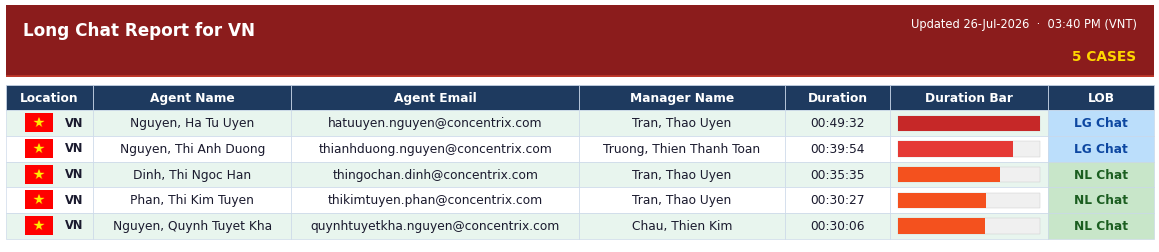


───────────────────────────────────────────────────────
✅  Lodging Long Chat Global  —  2 cases  |  1130x171 px


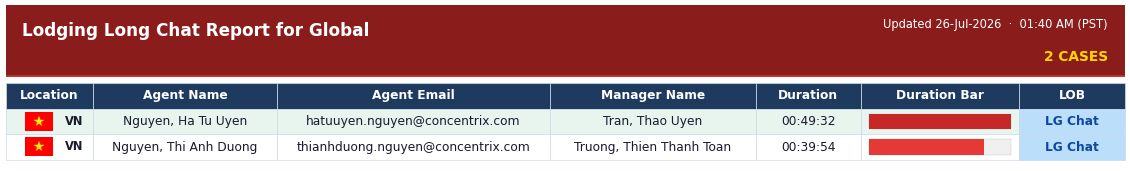


───────────────────────────────────────────────────────
✅  Non-Lodging Long Chat Global  —  5 cases  |  1188x252 px


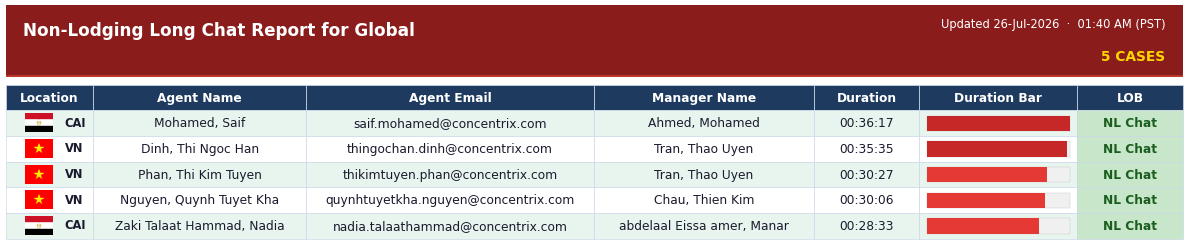


───────────────────────────────────────────────────────
✅  Lodging Long Voice Global  —  1 cases  |  985x143 px


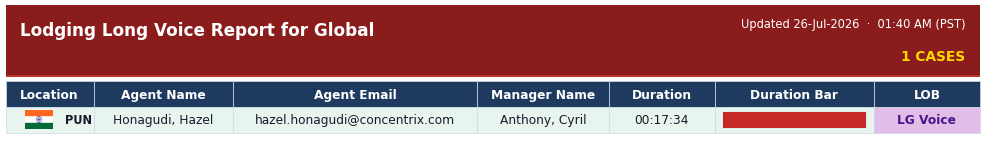


───────────────────────────────────────────────────────
✅  Non-Lodging Long Voice Global  —  1 cases  |  956x143 px


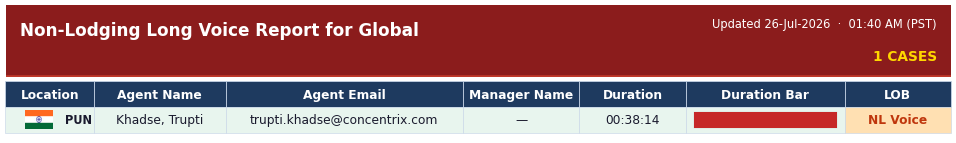


───────────────────────────────────────────────────────
👆 Kiểm tra xong → chạy Cell gửi Teams


In [119]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
import matplotlib.image as mpimg
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import pandas as pd
import numpy as np
from PIL import Image
import requests
import io
from datetime import datetime, timedelta

# ── Palette ────────────────────────────────────────────────────────────
BANNER_BG    = "#8B1C1C"
BANNER_TEXT  = "#ffffff"
SUBTITLE_CLR = "#ffffff"
CASES_COLOR  = "#FFD700"
ACCENT_LINE  = "#c0392b"
HEADER_COLOR = "#1e3a5f"
ROW_ODD      = "#e8f5ee"
ROW_EVEN     = "#ffffff"
TEXT_COLOR   = "#1a1a2e"
BORDER_COLOR = "#c8d6e8"
BAR_TRACK    = "#f0f0f0"
MAX_PX       = 3000
FONT_SIZE    = 8
CHAR_WIDTH   = 0.085
MIN_COL_W    = 1.2
ROW_H_INCH   = 0.32
BANNER_H     = 0.85

LOB_COLORS = {
    "LG Chat":  {"bg": "#BBDEFB", "text": "#0D47A1"},
    "NL Chat":  {"bg": "#C8E6C9", "text": "#1B5E20"},
    "LG Voice": {"bg": "#E1BEE7", "text": "#4A148C"},
    "NL Voice": {"bg": "#FFE0B2", "text": "#BF360C"},
}

DROP_COLS = [
    "sheet_name", "Export time",
    "Evaluate Endpoint", "Barge Endpoint",
    "Queue Name", "Agent Manager", "Conversation ID", "LC",
]

# ── Flag config ────────────────────────────────────────────────────────
FLAG_URL = "https://flagcdn.com/w40/{cc}.png"
FLAG_CC  = {"VN": "vn", "PUN": "in", "KOL": "in", "CAI": "eg"}
_flag_cache = {}

def get_flag(loc_code: str):
    cc = FLAG_CC.get(loc_code)
    if not cc:
        return None
    if cc in _flag_cache:
        return _flag_cache[cc]
    try:
        resp = requests.get(FLAG_URL.format(cc=cc), timeout=5)
        img  = Image.open(io.BytesIO(resp.content)).convert("RGBA")
        img  = img.resize((36, 24), Image.LANCZOS)
        _flag_cache[cc] = np.array(img)
        return _flag_cache[cc]
    except Exception as e:
        print(f"⚠️  Flag load failed [{loc_code}]: {e}")
        return None

# ── Helpers ────────────────────────────────────────────────────────────
def calc_col_widths(df: pd.DataFrame, extra: float = 0.3) -> list:
    widths = []
    for col in df.columns:
        max_len = max(len(str(col)), df[col].astype(str).str.len().max())
        widths.append(max(MIN_COL_W, max_len * CHAR_WIDTH + extra))
    return widths

def seconds_to_hms(s) -> str:
    try:
        s = int(float(s))
        h, r   = divmod(s, 3600)
        m, sec = divmod(r, 60)
        return f"{h:02d}:{m:02d}:{sec:02d}"
    except Exception:
        return "—"

def _bar_color(ratio: float) -> str:
    if ratio >= 0.90: return "#C62828"
    if ratio >= 0.75: return "#E53935"
    if ratio >= 0.60: return "#F4511E"
    if ratio >= 0.45: return "#FB8C00"
    if ratio >= 0.30: return "#FDD835"
    if ratio >= 0.15: return "#8BC34A"
    return "#2E7D32"

# ── Main render ────────────────────────────────────────────────────────
def df_to_image(df: pd.DataFrame, title: str, is_global: bool = False) -> Image.Image:
    now = datetime.now()
    if is_global:
        now = now - timedelta(hours=14)
    realtime      = now.strftime("%I:%M %p")
    realtime_date = now.strftime("%d-%b-%Y")
    timezone      = "(PST)" if is_global else "(VNT)"
    n_cases       = len(df)

    # ── Prepare DataFrame ──────────────────────────────────────────────
    df_show = df.reset_index(drop=True).fillna("—")
    df_show = df_show.drop(columns=[c for c in DROP_COLS if c in df_show.columns])

    # ── Bar ratios + convert Duration (s) → HH:MM:SS ──────────────────
    if "Duration (s)" in df_show.columns:
        secs       = df_show["Duration (s)"].astype(float)
        max_s      = secs.max() if secs.max() > 0 else 1
        bar_ratios = (secs / max_s).tolist()
        df_show["Duration (s)"] = secs.apply(seconds_to_hms)
        df_show = df_show.rename(columns={"Duration (s)": "Duration"})
        pos = df_show.columns.get_loc("Duration") + 1
    else:
        bar_ratios = [0.0] * len(df_show)
        pos        = len(df_show.columns)

    df_show.insert(pos, "Duration Bar", "")

    n_rows, n_cols = len(df_show), len(df_show.columns)
    col_names      = list(df_show.columns)
    dur_col_idx    = col_names.index("Duration Bar")
    loc_col_idx    = col_names.index("Location") if "Location" in col_names else -1
    lob_col_idx    = col_names.index("LOB")       if "LOB"      in col_names else -1

    # ── Layout ────────────────────────────────────────────────────────
    col_widths              = calc_col_widths(df_show)
    col_widths[dur_col_idx] = 1.8
    if loc_col_idx >= 0:
        col_widths[loc_col_idx] = 1.0 

    fig_w = min(sum(col_widths) + 0.4, 40)
    fig_h = BANNER_H + n_rows * ROW_H_INCH + 0.4

    fig = plt.figure(figsize=(fig_w, fig_h), facecolor="white")
    gs  = gridspec.GridSpec(
        2, 1, figure=fig,
        height_ratios=[BANNER_H, fig_h - BANNER_H],
        hspace=0.0
    )

    # ── Banner ────────────────────────────────────────────────────────
    ax_b = fig.add_subplot(gs[0])
    ax_b.set_xlim(0, 1)
    ax_b.set_ylim(0, 1)
    ax_b.axis("off")

    ax_b.add_patch(patches.FancyBboxPatch(
        (0, 0), 1, 1, boxstyle="square,pad=0",
        transform=ax_b.transAxes,
        facecolor=BANNER_BG, edgecolor="none",
        zorder=0, clip_on=False
    ))
    ax_b.text(
        0.015, 0.64, title,
        ha="left", va="center", transform=ax_b.transAxes,
        fontsize=11, fontweight="bold", color=BANNER_TEXT, zorder=2
    )
    ax_b.text(
        0.985, 0.73,
        f"Updated {realtime_date}  ·  {realtime} {timezone}",
        ha="right", va="center", transform=ax_b.transAxes,
        fontsize=7.5, color=SUBTITLE_CLR, zorder=2
    )
    ax_b.text(
        0.985, 0.28, f"{n_cases} CASES",
        ha="right", va="center", transform=ax_b.transAxes,
        fontsize=9, fontweight="bold", color=CASES_COLOR, zorder=2
    )
    ax_b.axhline(y=0, color=ACCENT_LINE, linewidth=3, zorder=3)

    # ── Table ─────────────────────────────────────────────────────────
    ax = fig.add_subplot(gs[1])
    ax.set_facecolor("white")
    ax.axis("off")

    total_w     = sum(col_widths)
    col_w_ratio = [w / total_w for w in col_widths]

    tbl = ax.table(
        cellText  = df_show.values.tolist(),
        colLabels = col_names,
        colWidths = col_w_ratio,
        cellLoc   = "center",
        loc       = "center",
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(FONT_SIZE)
    tbl.scale(1, 1.4)

    # Header
    for c in range(n_cols):
        cell = tbl[0, c]
        cell.set_facecolor(HEADER_COLOR)
        cell.set_edgecolor(BORDER_COLOR)
        cell.set_linewidth(0.5)
        cell.set_text_props(color="white", fontweight="bold")

    # Data rows
    for r in range(1, n_rows + 1):
        bg = ROW_ODD if r % 2 == 1 else ROW_EVEN
        for c in range(n_cols):
            cell = tbl[r, c]
            cell.set_facecolor(bg)
            cell.set_edgecolor(BORDER_COLOR)
            cell.set_linewidth(0.4)
            cell.set_text_props(color=TEXT_COLOR)

        if loc_col_idx >= 0:
            tbl[r, loc_col_idx].get_text().set_text("")

        # LOB
        if lob_col_idx >= 0:
            lob_val   = str(df_show.iloc[r - 1]["LOB"])
            lob_style = LOB_COLORS.get(lob_val)
            if lob_style:
                tbl[r, lob_col_idx].set_facecolor(lob_style["bg"])
                tbl[r, lob_col_idx].set_text_props(
                    color=lob_style["text"], fontweight="bold"
                )

        # Duration Bar — clear text
        tbl[r, dur_col_idx].get_text().set_text("")

    # Trigger layout
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    inv      = ax.transAxes.inverted()

    # ── Flag overlay ───────────────────────────────────────────────────
    if loc_col_idx >= 0:
        for r in range(1, n_rows + 1):
            loc_val  = str(df_show.iloc[r - 1]["Location"])
            flag_arr = get_flag(loc_val)

            cell = tbl[r, loc_col_idx]
            bbox = cell.get_window_extent(renderer=renderer)
            cx   = (bbox.x0 + bbox.x1) / 2
            cy   = (bbox.y0 + bbox.y1) / 2

            if flag_arr is None:
                cell.get_text().set_text(loc_val)
            else:
                cell.get_text().set_text("")

                flag_cx, flag_cy = inv.transform((cx - 10, cy))
                oi = OffsetImage(flag_arr, zoom=0.50)
                ab = AnnotationBbox(
                    oi, (flag_cx, flag_cy),
                    xycoords="axes fraction",
                    frameon=False, zorder=8
                )
                ax.add_artist(ab)

                text_x, text_y = inv.transform((cx + 14, cy))
                ax.text(
                    text_x, text_y, loc_val,
                    transform=ax.transAxes,
                    fontsize=FONT_SIZE - 0.5,
                    fontweight="bold",
                    color=TEXT_COLOR,
                    ha="left", va="center",
                    zorder=9
                )

    # ── Duration Bar overlay ──────────────────────────────────────────
    for r in range(1, n_rows + 1):
        ratio     = bar_ratios[r - 1]
        bar_color = _bar_color(ratio)
        cell      = tbl[r, dur_col_idx]

        bbox        = cell.get_window_extent(renderer=renderer)
        x0_a, y0_a = inv.transform((bbox.x0, bbox.y0))
        x1_a, y1_a = inv.transform((bbox.x1, bbox.y1))

        px      = (x1_a - x0_a) * 0.05
        py      = (y1_a - y0_a) * 0.20
        track_w = (x1_a - x0_a) - 2 * px
        bar_h   = (y1_a - y0_a) - 2 * py
        bar_w   = track_w * ratio

        ax.add_patch(patches.Rectangle(
            (x0_a + px, y0_a + py), track_w, bar_h,
            transform=ax.transAxes,
            facecolor=BAR_TRACK, edgecolor="#cccccc",
            linewidth=0.3, zorder=5
        ))
        if ratio > 0:
            ax.add_patch(patches.Rectangle(
                (x0_a + px, y0_a + py), bar_w, bar_h,
                transform=ax.transAxes,
                facecolor=bar_color, edgecolor="none", zorder=6
            ))
            ax.add_patch(patches.Rectangle(
                (x0_a + px, y0_a + py), bar_w, bar_h,
                transform=ax.transAxes,
                facecolor="none", edgecolor="none",
                hatch='......', alpha=0.3, zorder=7
            ))

    # ── Save ──────────────────────────────────────────────────────────
    buf = io.BytesIO()
    plt.savefig(buf, format="png", bbox_inches="tight",
                dpi=110, facecolor="white", pad_inches=0.05)
    plt.close(fig)
    buf.seek(0)
    image = Image.open(buf).copy()
    buf.close()

    w, h = image.size
    if w > MAX_PX or h > MAX_PX:
        scale = min(MAX_PX / w, MAX_PX / h)
        image = image.resize((int(w * scale), int(h * scale)), Image.LANCZOS)
        print(f"  ↳ Resized {w}x{h} → {image.size[0]}x{image.size[1]}")

    return image

def save_df_image_if_not_empty(df, title, is_global=False):
    if df is None or df.empty:
        print(f"⏭️  '{title}' — empty")
        return None
    return df_to_image(df, title, is_global=is_global)

# ── Generate ───────────────────────────────────────────────────────────
img_hcm        = save_df_image_if_not_empty(hcm_lc_pd,     "Long Chat Report for VN",                  is_global=False)
img_global_lg  = save_df_image_if_not_empty(global_lg_pd,  "Lodging Long Chat Report for Global",      is_global=True)
img_global_nl  = save_df_image_if_not_empty(global_nl_pd,  "Non-Lodging Long Chat Report for Global",  is_global=True)
img_global_lgv = save_df_image_if_not_empty(global_lgv_pd, "Lodging Long Voice Report for Global",     is_global=True)
img_global_nlv = save_df_image_if_not_empty(global_nlv_pd, "Non-Lodging Long Voice Report for Global", is_global=True)

# ── Preview ────────────────────────────────────────────────────────────
for name, img, cases in [
    ("Long Chat VN",                  img_hcm,        LC_Cases_hcm),
    ("Lodging Long Chat Global",      img_global_lg,  LC_Cases_global_lg),
    ("Non-Lodging Long Chat Global",  img_global_nl,  LC_Cases_global_nl),
    ("Lodging Long Voice Global",     img_global_lgv, LV_Cases_global_lg),
    ("Non-Lodging Long Voice Global", img_global_nlv, LV_Cases_global_nl),
]:
    print(f"\n{'─'*55}")
    if img is None:
        print(f"⏭️  {name}  —  skipped")
    else:
        print(f"✅  {name}  —  {cases} cases  |  {img.size[0]}x{img.size[1]} px")
        display(img)

print(f"\n{'─'*55}")
print("👆 Kiểm tra xong → chạy Cell gửi Teams")

In [120]:
# from io import BytesIO
# import pyperclip
# import PIL.ImageGrab
# from selenium.webdriver.support import expected_conditions as EC

# def wait_for_teams_loaded(driver, timeout=30):
#     wait = WebDriverWait(driver, timeout)
#     wait.until(EC.invisibility_of_element_located((By.ID, "loading-screen-logo")))
#     time.sleep(2)

# def send_report_to_group(driver, teams_url, group_chat_name, report_name, image, LC_Cases, is_global=False):
#     if LC_Cases == 0:
#         print(f"Skipping sending report '{report_name}' because LC_Cases == 0")
#         return

#     send_to_clipboard(image)

#     current_url = driver.current_url
#     if not current_url.startswith(teams_url):
#         driver.get(teams_url)
#         time.sleep(5)

#     wait_for_teams_loaded(driver, timeout=30)

#     wait = WebDriverWait(driver, 20)
#     try:
#         group_chat = wait.until(
#             EC.element_to_be_clickable(
#                 (By.XPATH, f"//span[contains(text(),'{group_chat_name}')]")
#             )
#         )
#         driver.execute_script("arguments[0].scrollIntoView(true);", group_chat)
#         time.sleep(0.5)
#         driver.execute_script("arguments[0].click();", group_chat)
#     except Exception as e:
#         print(f"Không tìm thấy nhóm chat '{group_chat_name}':", e)
#         return

#     time.sleep(3)
#     chat_box = wait.until(EC.element_to_be_clickable((By.CSS_SELECTOR, "div[role='textbox']")))
#     chat_box.click()

#     now = datetime.now()
#     if is_global:
#         now = now - timedelta(hours=14)
#     realtime = now.strftime("%I:%M %p")
#     timezone = "(PST)" if is_global else "(VNT)"
#     chat_text = f"The {report_name} was updated at {realtime} {timezone}"

#     actions = ActionChains(driver)
#     actions.send_keys("@everyone").perform()
#     time.sleep(0.5)
#     actions.send_keys(Keys.ENTER).perform()
#     actions.send_keys(" ")
#     actions.send_keys(chat_text)
#     actions.perform()
#     time.sleep(2)

#     actions = ActionChains(driver)
#     actions.key_down(Keys.CONTROL).send_keys('v').key_up(Keys.CONTROL).perform()
#     time.sleep(2)
#     actions.send_keys(Keys.ENTER).perform()
#     time.sleep(10)

# send_report_to_group(driver, teams_url, "[Expedia VN] BOT", "Long Chat Report for VN", img_hcm, LC_Cases_hcm, is_global=False)
# send_report_to_group(driver, teams_url, "[Expedia VN] BOT", "Lodging Long Chat Report for Global", img_global_lg, LC_Cases_global_lg, is_global=True)
# send_report_to_group(driver, teams_url, "[Expedia VN] BOT", "Non-Lodging Long Chat Report for Global", img_global_nl, LC_Cases_global_nl, is_global=True)
# send_report_to_group(driver, teams_url, "[Expedia VN] BOT", "Lodging Long Voice Report for Global", img_global_lgv, LV_Cases_global_lg, is_global=True)
# send_report_to_group(driver, teams_url, "[Expedia VN] BOT", "Non-Lodging Long Voice Report for Global", img_global_nlv, LV_Cases_global_nl, is_global=True)

# driver.quit()

In [ ]:
import requests
import json
import pandas as pd
from datetime import datetime, timedelta

# ── Paste URL từ Teams Workflow ────────────────────────────────────────
TEAMS_WEBHOOK_URL = "https://default599e51d62f8c43478e591f795a51a9.8c.environment.api.powerplatform.com:443/powerautomate/automations/direct/workflows/f0a5e82911b04a54bb3bd583e650a123/triggers/manual/paths/invoke?api-version=1&sp=%2Ftriggers%2Fmanual%2Frun&sv=1.0&sig=SgQKFUlTwwp-g8Rbj48-xXzYQoshgolN-n7T8tqKbiY"

def seconds_to_hms(s) -> str:
    try:
        s = int(float(s))
        h, r   = divmod(s, 3600)
        m, sec = divmod(r, 60)
        return f"{h:02d}:{m:02d}:{sec:02d}"
    except Exception:
        return "—"

def make_row_columnset(values, col_widths, is_header=False):
    columns = []
    for val, w in zip(values, col_widths):
        columns.append({
            "type": "Column",
            "width": str(w),
            "items": [{
                "type": "TextBlock",
                "text": f"**{val}**" if is_header else str(val),
                "size": "small",
                "color": "dark",
                "wrap": True
            }]
        })
    return {
        "type": "ColumnSet",
        "columns": columns,
        "separator": not is_header,
        "spacing": "none"
    }

def build_adaptive_card(df: pd.DataFrame, title: str, is_global: bool = False, lc_cases: int = 0) -> dict:
    now = datetime.now()
    if is_global:
        now = now - timedelta(hours=14)
    realtime = now.strftime("%I:%M %p")
    timezone = "(PST)" if is_global else "(VNT)"
    subtitle = f"Updated {now.strftime('%d-%b-%Y')}  ·  {realtime} {timezone}"

    # ── Prep DataFrame ─────────────────────────────────────────────────
    df = df.copy()
    drop = ["Duration Bar", "sheet_name", "Export time"]
    df   = df.drop(columns=[c for c in drop if c in df.columns])

    if "Duration (s)" in df.columns:
        df["Duration"] = df["Duration (s)"].apply(seconds_to_hms)
        df = df.drop(columns=["Duration (s)"])

    col_names = list(df.columns)

    # ── Column widths — chỉ integer ────────────────────────────────────
    COL_WIDTH_MAP = {
        "Location":     1,
        "Agent Name":   2,
        "Agent Email":  3,
        "Manager Name": 2,
        "Duration":     1,
        "LOB":          1,
    }
    col_widths = [int(COL_WIDTH_MAP.get(c, 2)) for c in col_names]

    # ── Build rows dùng ColumnSet ──────────────────────────────────────
    rows_ui = [make_row_columnset(col_names, col_widths, is_header=True)]
    for _, row in df.iterrows():
        values = [str(row[c]) if pd.notna(row[c]) else "—" for c in col_names]
        rows_ui.append(make_row_columnset(values, col_widths, is_header=False))

    # ── Full card ──────────────────────────────────────────────────────
    return {
        "$schema": "http://adaptivecards.io/schemas/adaptive-card.json",
        "type": "AdaptiveCard",
        "version": "1.5",
        "msteams": {"width": "Full"},
        "body": [
            # Title
            {
                "type": "TextBlock",
                "text": f"🔴 **{title}**",
                "weight": "bolder",
                "size": "large",
                "color": "attention",
                "wrap": False
            },
            # Subtitle + cases
            {
                "type": "ColumnSet",
                "columns": [
                    {
                        "type": "Column",
                        "width": "stretch",
                        "items": [{
                            "type": "TextBlock",
                            "text": subtitle,
                            "size": "small",
                            "isSubtle": True,
                            "wrap": False
                        }]
                    },
                    {
                        "type": "Column",
                        "width": "auto",
                        "items": [{
                            "type": "TextBlock",
                            "text": f"⚡ **{lc_cases} CASES**",
                            "size": "medium",
                            "color": "warning",
                            "weight": "bolder",
                            "horizontalAlignment": "right"
                        }]
                    }
                ]
            },
            # Separator
            {
                "type": "TextBlock",
                "text": " ",
                "separator": True,
                "spacing": "small"
            },
            # Table rows dùng ColumnSet
            *rows_ui
        ]
    }

def send_via_webhook(df, title, is_global=False, lc_cases=0):
    if lc_cases == 0:
        print(f"⏭️  Skipping '{title}' — 0 cases")
        return
    if df is None or df.empty:
        print(f"⏭️  Skipping '{title}' — empty")
        return

    card = build_adaptive_card(df, title, is_global, lc_cases)

    payload = {
        "attachments": [{
            "contentType": "application/vnd.microsoft.card.adaptive",
            "content": card
        }]
    }

    try:
        resp = requests.post(
            TEAMS_WEBHOOK_URL,
            headers={"Content-Type": "application/json"},
            data=json.dumps(payload),
            timeout=30
        )
        if resp.status_code in (200, 202):
            print(f"✅ Sent: '{title}'  ({lc_cases} cases)")
        else:
            print(f"❌ Failed [{resp.status_code}]: '{title}'\n   {resp.text[:300]}")
    except Exception as e:
        print(f"❌ Error: {e}")

# ── Gửi 5 bảng ────────────────────────────────────────────────────────
send_via_webhook(hcm_lc_pd,     "Long Chat Report for VN",                 is_global=False, lc_cases=LC_Cases_hcm)
send_via_webhook(global_lg_pd,  "Lodging Long Chat Report for Global",     is_global=True,  lc_cases=LC_Cases_global_lg)
send_via_webhook(global_nl_pd,  "Non-Lodging Long Chat Report for Global", is_global=True,  lc_cases=LC_Cases_global_nl)
send_via_webhook(global_lgv_pd, "Lodging Long Voice Report for Global",    is_global=True,  lc_cases=LV_Cases_global_lg)
send_via_webhook(global_nlv_pd, "Non-Lodging Long Voice Report for Global",is_global=True,  lc_cases=LV_Cases_global_nl)

✅ Sent: 'Long Chat Report for VN'  (5 cases)
✅ Sent: 'Lodging Long Chat Report for Global'  (2 cases)
✅ Sent: 'Non-Lodging Long Chat Report for Global'  (5 cases)
✅ Sent: 'Lodging Long Voice Report for Global'  (1 cases)
✅ Sent: 'Non-Lodging Long Voice Report for Global'  (1 cases)
